In [ ]:
import pandas as pd
#load the dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")
#displaying the dataset first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
print(df.shape)      # number of rows and columns
print(df.columns)    # column names
print(df.info())     # data types and missing values
print(df.describe()) # statistical summary

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count 

In [ ]:
#check missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#handing missing values
# Age → fill with median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Embarked → fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
#1.Label Encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler# Select numerical columns
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Standardization (Z-score normalization)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age     SibSp  \
0                            Braund, Mr. Owen Harris    0 -0.565736  0.432793   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  0.663861  0.432793   
2                             Heikkinen, Miss. Laina    1 -0.258337 -0.474545   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  0.433312  0.432793   
4                           Allen, Mr. William Henry    0  0.433312 -0.474545   

      Parch            Ticket      Fare  Embarked_Q  Embarked_S  
0 -0.473674         A/5 21171 -0.502445       False        True  
1 -0.473674          PC 17599  0.786845       False       False  
2 -0.473674  STON/O2. 3101282 -0.488854       False        True  
3 -0.473674            113803  0

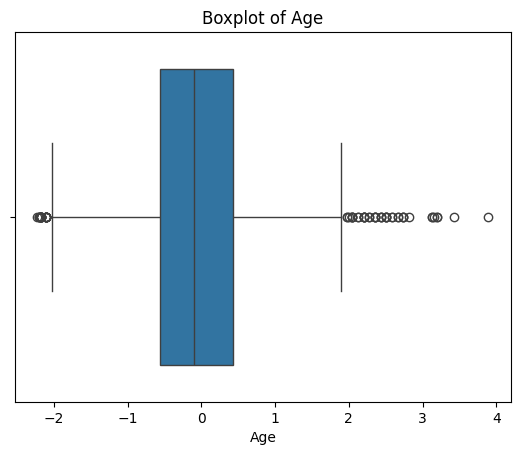

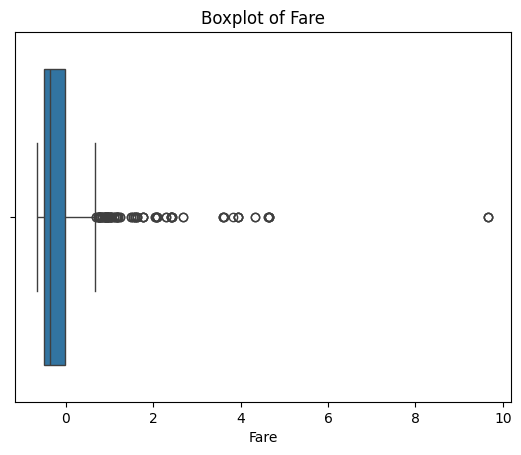

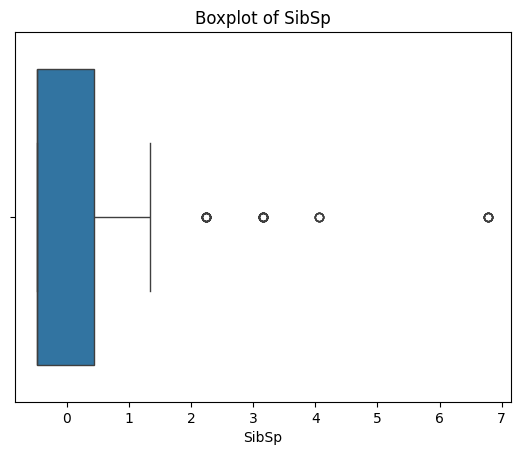

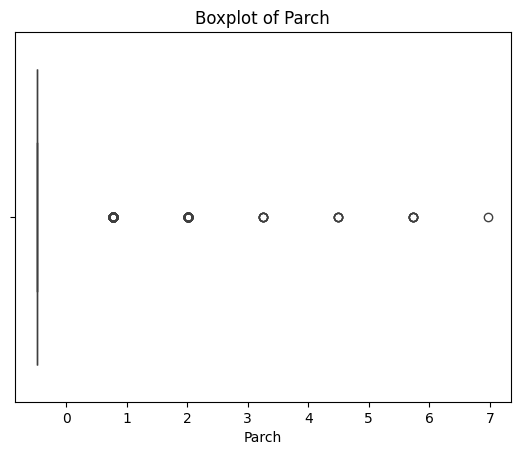

(577, 12)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# --- Visualize outliers using boxplots ---
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# --- Remove outliers using IQR method ---
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Final shape after removing outliers
print(df.shape)

Task 2


In [ ]:
#1.generate summary statistics(mean,meadian,std,etc.).
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


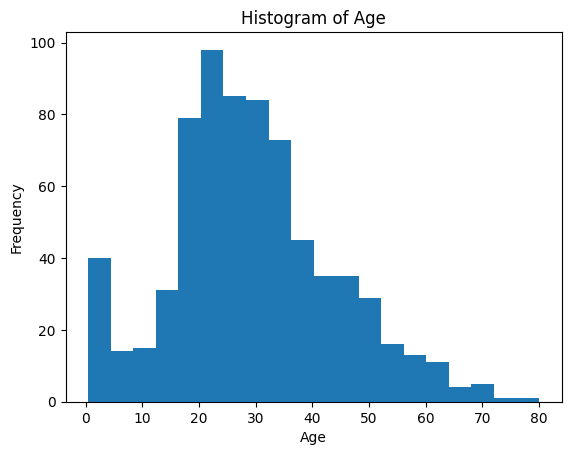

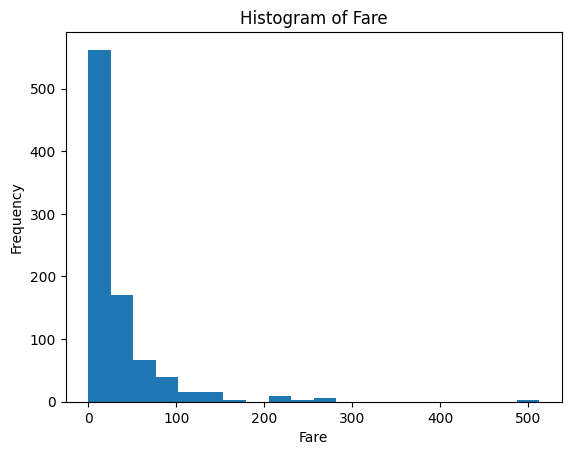

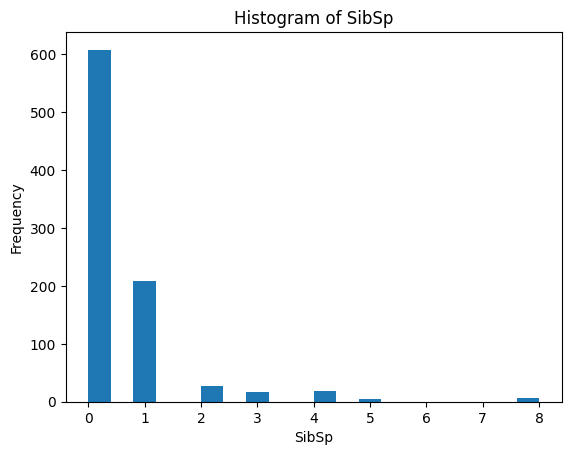

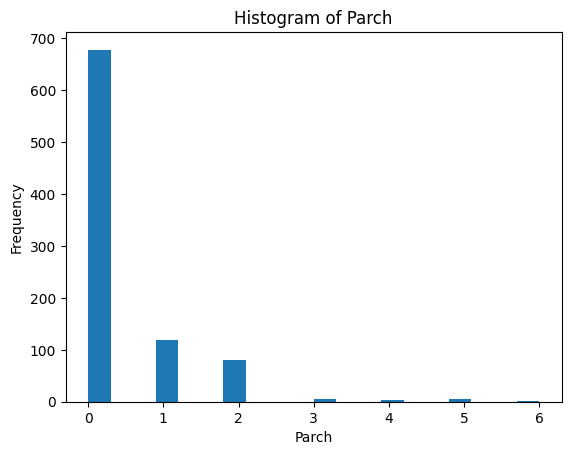

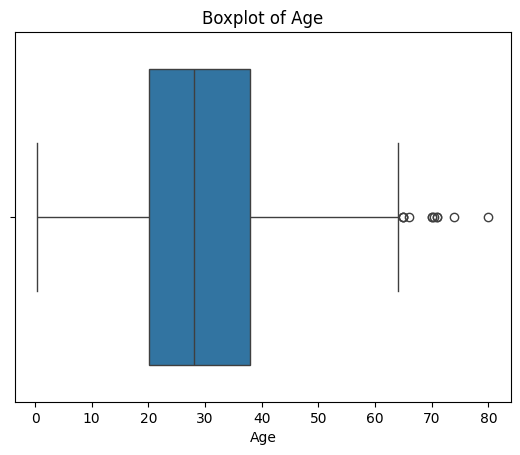

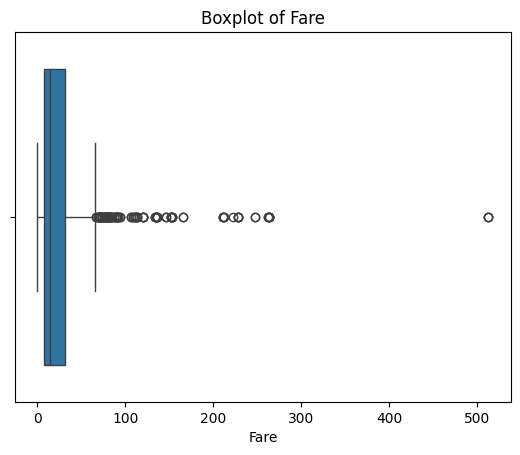

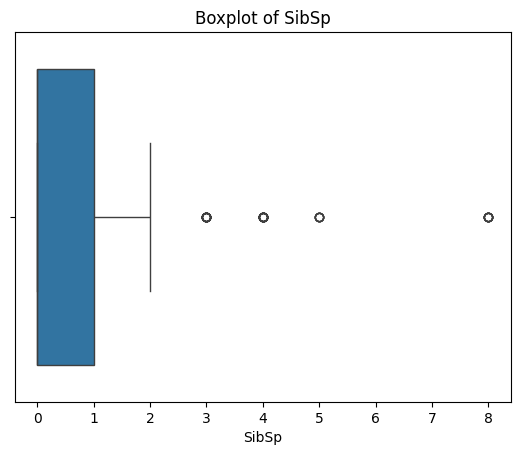

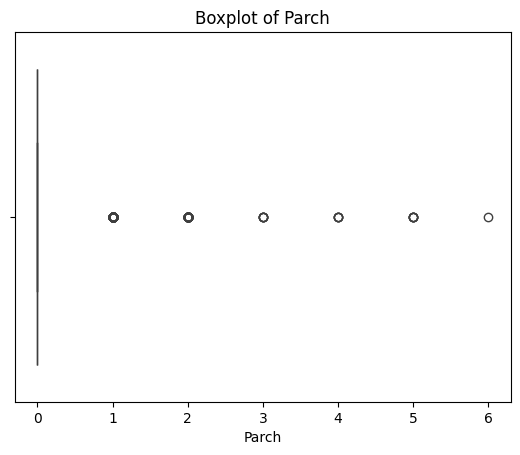

In [ ]:
#create histogram and boxplots for numeric features
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

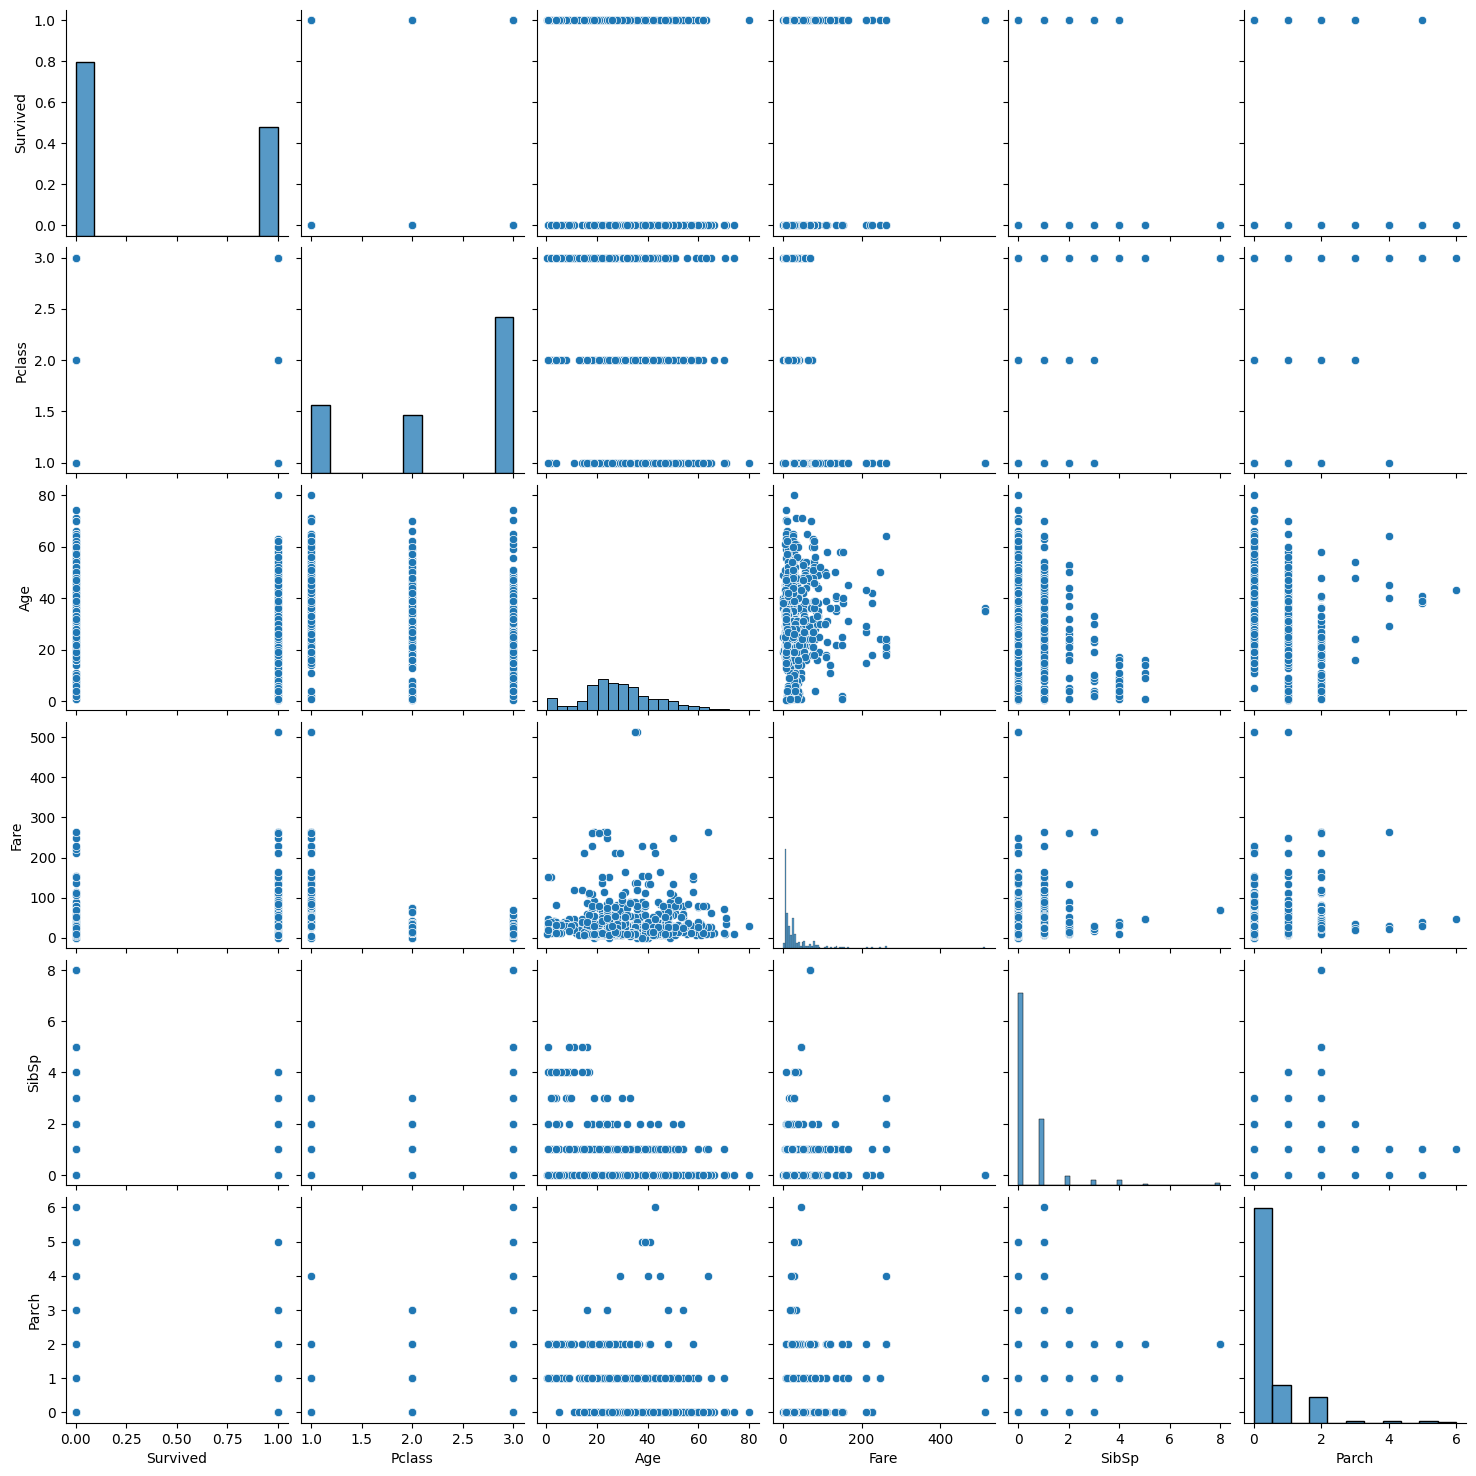

In [ ]:
sns.pairplot(df[['Survived','Pclass','Sex','Age','Fare','SibSp','Parch']])
plt.show()

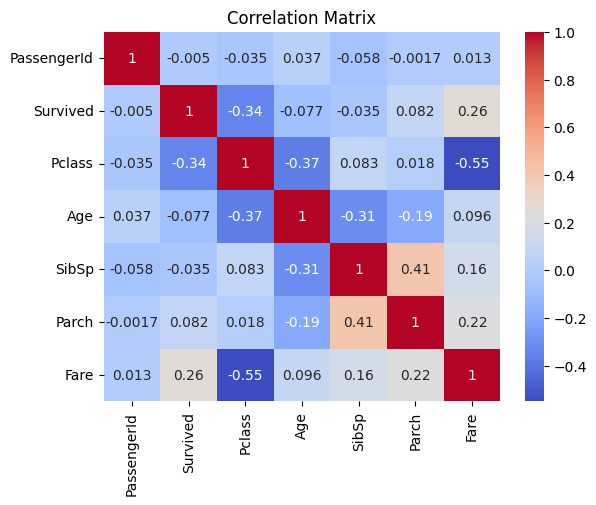

In [ ]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#4.Identify patterns, trends, or anomalies in the data.



# From the analysis, gender, passenger class, and fare show the strongest impact on survival. Females and higher-class passengers had better survival chances, and people who paid higher fares were more likely to survive. Age has very little effect on survival.
# There is also a strong relationship between fare and class, where higher-class passengers paid more. Some outliers are present, especially in fare, and a few exceptions exist where high-class passengers did not survive and some low-class passengers did.
# Overall, the main factors affecting survival are sex, class, and fare, while other features have weaker influence.

In [ ]:
# 5.Make basic feature-level inferences from visuals.

#From the visualizations, it is clear that Sex, Pclass, and Fare are the most important features. Females have a higher survival rate compared to males, and passengers in 1st class survived more than those in lower classes. Higher fare values are also associated with better survival chances.
# Age does not show a strong pattern, as survival is spread across different age groups. Features like SibSp and Parch have a weaker impact, although passengers with smaller families seem to have slightly better survival.
# Overall, the visuals suggest that gender, class, and fare play a major role in survival, while other features have limited influence.